import libraries

In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


load data 

In [175]:
data=pd.read_csv("dataAIrBnb.csv")
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1,Clinton Hill Apartment Single Bedroom ! Pratt ~~,30610258,Santiago,Brooklyn,Clinton Hill,40.69591,-73.96284,Private room,58,2,1,9/23/2018,0.10,1,0
1,2,Andy Phillips,6180052,Andrian,Brooklyn,Fort Greene,40.68769,-73.97490,Private room,99,5,4,9/29/2017,0.17,1,250
2,3,"Stylish, Comfortable, and Affordable in Brooklyn",5957027,Zachary,Brooklyn,Crown Heights,40.67667,-73.91750,Entire home/apt,180,2,126,6/14/2019,3.74,1,74
3,4,15 min train ride to Times Sq and US OPEN,101602599,M,Queens,Woodside,40.74340,-73.90588,Entire home/apt,50,1,95,6/24/2019,5.63,2,0
4,5,Sunny 2 bdrm Park Slope Apt w/ Yard 3min to Su...,106168581,Jason,Brooklyn,South Slope,40.66600,-73.99020,Entire home/apt,210,4,88,7/4/2019,4.41,1,20


In [176]:
data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,27379.000000,2.737900e+04,27379.000000,27379.000000,27379.000000,27379.000000,27379.000000,21746.000000,27379.000000,27379.000000
mean,13690.000000,6.820276e+07,40.728836,-73.952071,151.569561,7.056722,23.228131,1.383797,7.228788,113.430293
std,7903.780846,7.910462e+07,0.054629,0.046278,219.807784,20.194945,44.281418,1.714116,33.173634,132.039807
min,1.000000,2.438000e+03,40.506410,-74.242850,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,6845.500000,7.971896e+06,40.689955,-73.983080,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,13690.000000,3.114212e+07,40.723030,-73.955700,105.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,20534.500000,1.074344e+08,40.763045,-73.935830,175.000000,5.000000,23.000000,2.030000,2.000000,230.000000
max,27379.000000,2.743213e+08,40.913060,-73.717950,10000.000000,999.000000,607.000000,58.500000,327.000000,365.000000


dropping down unrelated columns

In [177]:
data=data.drop(["id","host_id","name","host_name","neighbourhood","last_review","reviews_per_month","number_of_reviews"],axis=1)
data.head()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
0,Brooklyn,40.69591,-73.96284,Private room,58,2,1,0
1,Brooklyn,40.68769,-73.97490,Private room,99,5,1,250
2,Brooklyn,40.67667,-73.91750,Entire home/apt,180,2,1,74
3,Queens,40.74340,-73.90588,Entire home/apt,50,1,2,0
4,Brooklyn,40.66600,-73.99020,Entire home/apt,210,4,1,20


In [178]:
data.isnull().sum()

neighbourhood_group               0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [179]:
data.shape

(27379, 8)

checking outliers

In [180]:
def outliers(data,col):
    q1=data[col].quantile(0.25)
    q3=data[col].quantile(0.75)

    iqr= q1-1.5
    lower_bound=q1-1.5*iqr
    higher_bound=q1+1.5*iqr
    return data[(data[col] < lower_bound) | (data[col] > higher_bound)]



In [181]:
outliers(data,'price')

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
2,Brooklyn,40.67667,-73.91750,Entire home/apt,180,2,1,74
4,Brooklyn,40.66600,-73.99020,Entire home/apt,210,4,1,20
8,Manhattan,40.75976,-73.98761,Private room,249,1,9,283
17,Manhattan,40.75403,-73.96714,Entire home/apt,714,28,49,250
23,Manhattan,40.75880,-73.96611,Entire home/apt,260,30,87,341
...,...,...,...,...,...,...,...,...
27332,Brooklyn,40.71865,-73.96392,Entire home/apt,249,2,1,38
27336,Manhattan,40.74412,-73.99684,Entire home/apt,275,2,1,0
27355,Manhattan,40.74775,-73.99167,Entire home/apt,999,2,1,0
27357,Manhattan,40.73393,-73.99306,Private room,200,3,1,0


Text(0.5, 1.0, 'boxplot of price')

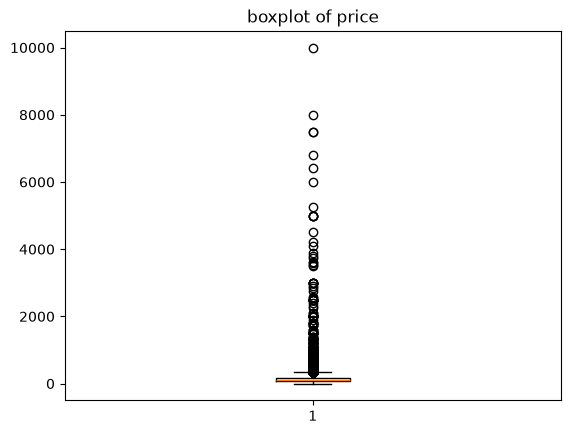

In [182]:
plt.Figure(figsize=(8,4))
plt.boxplot(x=data["price"])
plt.title("boxplot of price")

In [183]:
data["price"].sort_values(ascending=False).head(20)

18103    10000
7311      8000
26156     7500
17270     7500
7876      6800
8270      6419
4734      6000
27331     5250
7270      5000
6545      5000
21205     5000
17615     5000
17782     4500
5577      4200
23935     4100
8138      3900
25083     3800
19966     3750
6680      3613
4543      3600
Name: price, dtype: int64

In [184]:
data["price"].describe()

count    27379.000000
mean       151.569561
std        219.807784
min          0.000000
25%         69.000000
50%        105.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

fix outliers

Text(0.5, 1.0, 'boxplot of price after log1p')

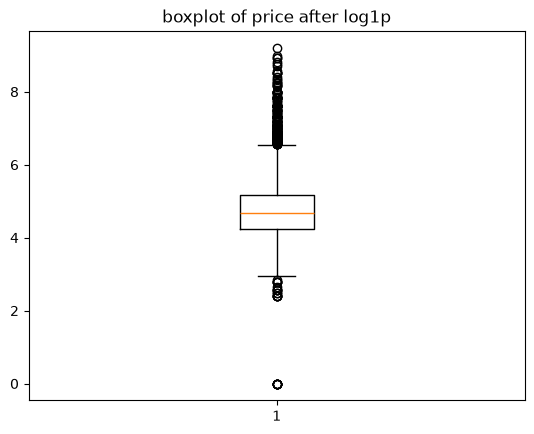

In [185]:
data["price_log"] = np.log1p(data["price"])
plt.Figure(figsize=(8,4))
plt.boxplot(x=data["price_log"])
plt.title("boxplot of price after log1p")

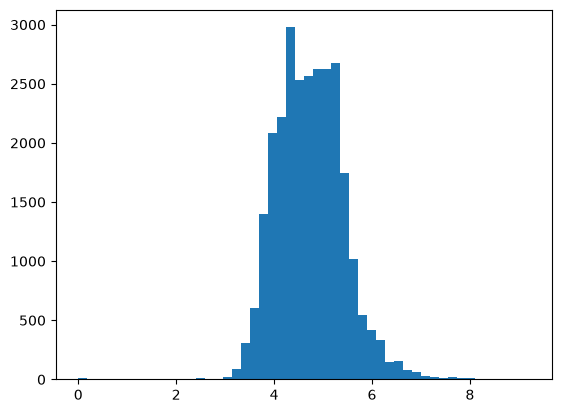

In [186]:
plt.hist(data["price_log"], bins=50)
plt.show()

In [187]:
data.head()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365,price_log
0,Brooklyn,40.69591,-73.96284,Private room,58,2,1,0,4.077537
1,Brooklyn,40.68769,-73.97490,Private room,99,5,1,250,4.605170
2,Brooklyn,40.67667,-73.91750,Entire home/apt,180,2,1,74,5.198497
3,Queens,40.74340,-73.90588,Entire home/apt,50,1,2,0,3.931826
4,Brooklyn,40.66600,-73.99020,Entire home/apt,210,4,1,20,5.351858


encodign : turning catogorical data into numerical data

In [188]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data["neighbourhood_group"] = encoder.fit_transform(data["neighbourhood_group"])
data["room_type"] = encoder.fit_transform(data["room_type"])
data.head()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365,price_log
0,1,40.69591,-73.96284,1,58,2,1,0,4.077537
1,1,40.68769,-73.97490,1,99,5,1,250,4.605170
2,1,40.67667,-73.91750,0,180,2,1,74,5.198497
3,3,40.74340,-73.90588,0,50,1,2,0,3.931826
4,1,40.66600,-73.99020,0,210,4,1,20,5.351858


In [189]:
data = pd.get_dummies(
    data,
    columns=["neighbourhood_group", "room_type"],
    drop_first=True
)

In [190]:
data.head()

,latitude,longitude,price,minimum_nights,calculated_host_listings_count,availability_365,price_log,neighbourhood_group_1,neighbourhood_group_2,neighbourhood_group_3,neighbourhood_group_4,room_type_1,room_type_2
0,40.69591,-73.96284,58,2,1,0,4.077537,True,False,False,False,True,False
1,40.68769,-73.97490,99,5,1,250,4.605170,True,False,False,False,True,False
2,40.67667,-73.91750,180,2,1,74,5.198497,True,False,False,False,False,False
3,40.74340,-73.90588,50,1,2,0,3.931826,False,False,True,False,False,False
4,40.66600,-73.99020,210,4,1,20,5.351858,True,False,False,False,False,False


train test split

In [191]:
from sklearn.model_selection import train_test_split
X = data.drop(["price", "price_log"], axis=1)
y = data["price_log"]
X_train,X_test,Y_train,Y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaling the data 

In [192]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Applying Model of the Data

In [193]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



lr_model = LinearRegression()

lr_model.fit(X_train, Y_train)

lr_prediction = lr_model.predict(X_test)

lr_pred_price = np.expm1(lr_prediction)
actual_price = np.expm1(Y_test)

lr_mae = mean_absolute_error(actual_price, lr_pred_price)
lr_rmse = np.sqrt(mean_squared_error(actual_price, lr_pred_price))
lr_r2 = r2_score(actual_price, lr_pred_price)

print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression
MAE: 58.93754795730683
RMSE: 164.09718981289367
R2: 0.1465157787661917


In [196]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, Y_train)

xgb_prediction = xgb_model.predict(X_test)

xgb_pred_price = np.expm1(xgb_prediction)

xgb_mae = mean_absolute_error(actual_price, xgb_pred_price)
xgb_rmse = np.sqrt(mean_squared_error(actual_price, xgb_pred_price))
xgb_r2 = r2_score(actual_price, xgb_pred_price)

print("XGBoost")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)



XGBoost
MAE: 52.845161580969766
RMSE: 156.30433809982495
R2: 0.22565362010770285


In [195]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, Y_train)

rf_prediction = rf_model.predict(X_test)

rf_pred_price = np.expm1(rf_prediction)

rf_mae = mean_absolute_error(actual_price, rf_pred_price)
rf_rmse = np.sqrt(mean_squared_error(actual_price, rf_pred_price))
rf_r2 = r2_score(actual_price, rf_pred_price)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest
MAE: 54.9030480292856
RMSE: 157.61585537265
R2: 0.21260434229867675


Three regression models were trained to predict Airbnb listing prices. After preprocessing, log transformation, and one-hot encoding, XGBoost achieved the best performance with an MAE of 52.85, RMSE of 156.30, and R² score of 0.226. This indicates that XGBoost was better able to capture the non-linear relationships present in the data compared to Linear Regression and Random Forest.